In [1]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os

load_dotenv()
rf = Roboflow(api_key=os.getenv("ROBOFLOW_API_KEY"))
project = rf.workspace("annas-workspace-w7hqa").project("pipe-ibz20")
version = project.version(2)
dataset = version.download("coco")
                

/home/cmgira/anaconda3/envs/PCSv1/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


loading Roboflow workspace...
loading Roboflow project...


# Building Dataset Class

In [2]:
import torch
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from PIL import Image
import numpy as np

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, annotation_file, transforms=None):
        self.img_dir = img_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img_info = self.coco.imgs[img_id]
        image = Image.open(f"{self.img_dir}/{img_info['file_name']}").convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        if len(anns) == 0:
            return None

        masks, boxes, labels = [], [], []
        for ann in anns:
            mask = self.coco.annToMask(ann)
            masks.append(mask)
            boxes.append(ann['bbox'])
            labels.append(ann['category_id'])

        masks = torch.as_tensor(np.array(masks), dtype=torch.uint8)
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        boxes[:, 2] += boxes[:, 0]
        boxes[:, 3] += boxes[:, 1]
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {"masks": masks, "boxes": boxes, "labels": labels, "image_id": torch.tensor([img_id])}

        if self.transforms:
            image = self.transforms(image)
        
        return image, target
    
    def __len__(self):
        return len(self.ids)

# Defining the Model

In [3]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_model(num_classes):
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)

    return model


In [4]:
print(os.getcwd())

/home/cmgira/cnefs-research/PCSv1/testing_workflow


# Training Loop

In [7]:
from torch.utils.data import DataLoader
import torchvision.transforms as T

# Defines number of classes (number of instances to look for, in this case we have 1: pipe)
NUM_CLASSES = 1
transforms = T.Compose([T.ToTensor()])
DATASET_ROOT = "/home/cmgira/cnefs-research/PCSv1/testing_workflow/pipe-2"

train_dataset = SegmentationDataset(
    img_dir=f"{DATASET_ROOT}/train",
    annotation_file=f"{DATASET_ROOT}/train/_annotations.coco.json",
    transforms=transforms
)

valid_dataset = SegmentationDataset(
    img_dir=f"{DATASET_ROOT}/valid",
    annotation_file=f"{DATASET_ROOT}/valid/_annotations.coco.json",
    transforms=transforms
)

train_loader = DataLoader(
    train_dataset, batch_size=2, shuffle=True,
    collate_fn=lambda x: tuple(zip(*[s for s in x if s is not None]))
)

valid_loader = DataLoader(
    valid_dataset, batch_size=2, shuffle=False,
    collate_fn=lambda x: tuple(zip(*[s for s in x if s is not None]))
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_model(num_classes=NUM_CLASSES + 1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

model.train()
images, targets = next(iter(train_loader))
images = [img.to(device) for img in images]
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

loss_dict = model(images, targets)
print(loss_dict)  # Should show individual loss components

for epoch in range(20):
    model.train()
    total_loss = 0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch + 1} | Loss: {total_loss / len(train_loader):.4f}")

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/cmgira/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:01<00:00, 97.6MB/s] 


{'loss_classifier': tensor(0.6804, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.6215, device='cuda:0', grad_fn=<DivBackward0>), 'loss_mask': tensor(2.6838, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_objectness': tensor(2.2643, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.4332, device='cuda:0', grad_fn=<DivBackward0>)}
Epoch 1 | Loss: 2.3228
Epoch 2 | Loss: 1.9355
Epoch 3 | Loss: 1.7472
Epoch 4 | Loss: 1.6201
Epoch 5 | Loss: 1.4946
Epoch 6 | Loss: 1.3114
Epoch 7 | Loss: 1.2035
Epoch 8 | Loss: 1.1249
Epoch 9 | Loss: 1.0599
Epoch 10 | Loss: 0.9937
Epoch 11 | Loss: 0.9372
Epoch 12 | Loss: 0.8723
Epoch 13 | Loss: 0.8266
Epoch 14 | Loss: 0.8060
Epoch 15 | Loss: 0.7788
Epoch 16 | Loss: 0.7455
Epoch 17 | Loss: 0.7084
Epoch 18 | Loss: 0.6935
Epoch 19 | Loss: 0.6777
Epoch 20 | Loss: 0.6682


Detections above threshold 0.5: 34
  [0] label=1, scores=0.998
  [1] label=1, scores=0.997
  [2] label=1, scores=0.994
  [3] label=1, scores=0.993
  [4] label=1, scores=0.990
  [5] label=1, scores=0.988
  [6] label=1, scores=0.982
  [7] label=1, scores=0.979
  [8] label=1, scores=0.979
  [9] label=1, scores=0.978
  [10] label=1, scores=0.969
  [11] label=1, scores=0.966
  [12] label=1, scores=0.948
  [13] label=1, scores=0.941
  [14] label=1, scores=0.939
  [15] label=1, scores=0.931
  [16] label=1, scores=0.928
  [17] label=1, scores=0.917
  [18] label=1, scores=0.917
  [19] label=1, scores=0.909
  [20] label=1, scores=0.896
  [21] label=1, scores=0.893
  [22] label=1, scores=0.889
  [23] label=1, scores=0.869
  [24] label=1, scores=0.867
  [25] label=1, scores=0.853
  [26] label=1, scores=0.836
  [27] label=1, scores=0.721
  [28] label=1, scores=0.708
  [29] label=1, scores=0.699
  [30] label=1, scores=0.688
  [31] label=1, scores=0.578
  [32] label=1, scores=0.552
  [33] label=1, sc

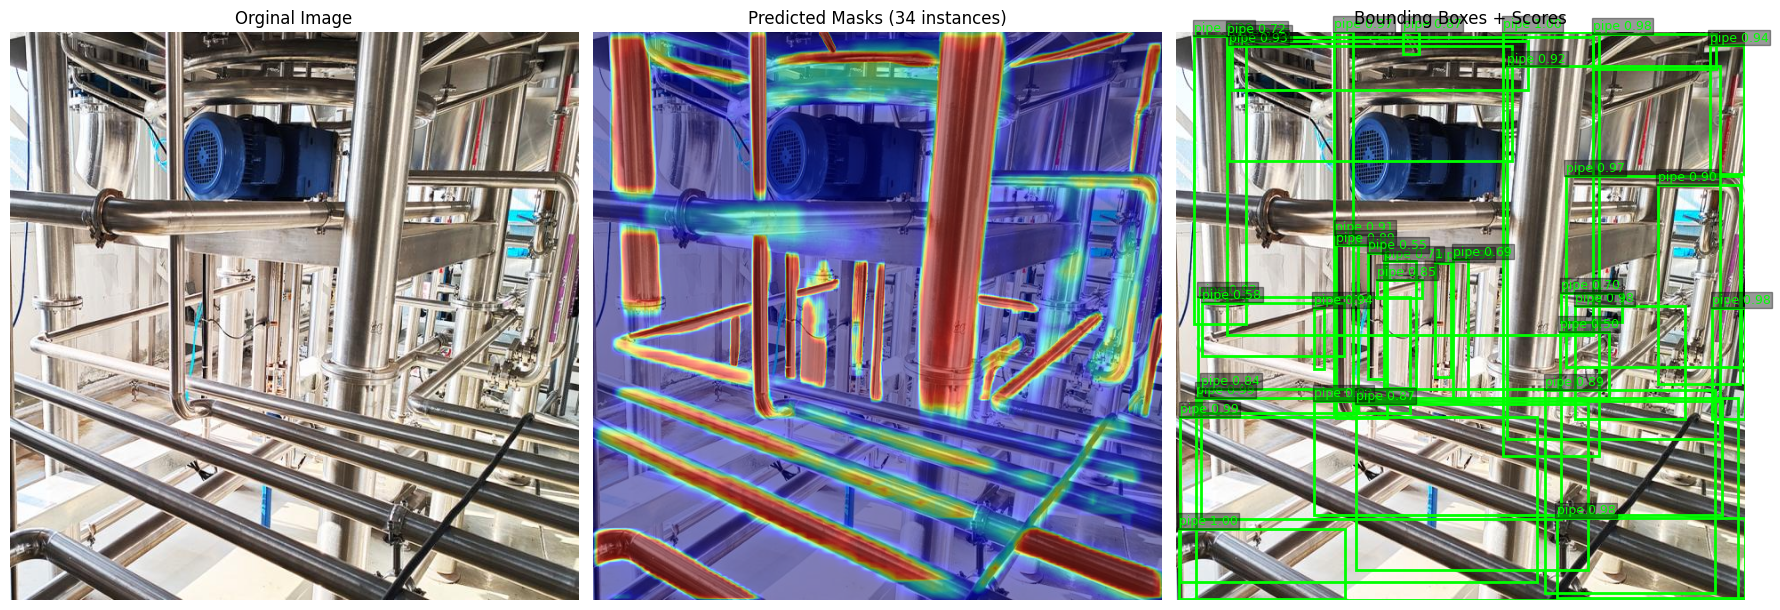

Saved to inference_output.png


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torchvision.transforms as T

def run_inference(model, image_path, device, threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)

    output = outputs[0]

    scores = output['scores'].cpu().numpy()
    masks = output['masks'].cpu().numpy()
    boxes = output['boxes'].cpu().numpy()
    labels = output['labels'].cpu().numpy()

    keep = scores >= threshold
    scores = scores[keep]
    masks = masks[keep]
    boxes = boxes[keep]
    labels = labels[keep]

    print(f"Detections above threshold {threshold}: {len(scores)}")
    for i, (s, l) in enumerate(zip(scores, labels)):
        print(f"  [{i}] label={l}, scores={s:.3f}")

    figs, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(image)
    axes[0].set_title("Orginal Image")
    axes[0].axis("off")

    axes[1].imshow(image)
    combined_mask = np.zeros((*np.array(image).shape[:2],), dtype=np.float32)
    for mask in masks:
        combined_mask = np.maximum(combined_mask, mask[0])  # merge masks
    axes[1].imshow(combined_mask, alpha=0.5, cmap='jet')
    axes[1].set_title(f"Predicted Masks ({len(masks)} instances)")
    axes[1].axis("off")

    # Boxes + scores
    axes[2].imshow(image)
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        axes[2].add_patch(rect)
        axes[2].text(x1, y1 - 5, f"pipe {score:.2f}",
                     color='lime', fontsize=9,
                     bbox=dict(facecolor='black', alpha=0.4, pad=1))
    axes[2].set_title("Bounding Boxes + Scores")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("inference_output.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to inference_output.png")

    return output
    
IMAGE_PATH = "/home/cmgira/cnefs-research/PCSv1/testing_workflow/pipe-2/valid/beer-equipment-Feb-eightteen-one_jpg.rf.c997a4c6db70189507ece7cd47c76b8e.jpg"
output = run_inference(model, IMAGE_PATH, device, threshold=0.5)